In [290]:
# Imports + cấu hình chung
from pathlib import Path
import json, os
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

# >>> dùng đúng model bạn đã train
from model.mtl_efficientnet_b0 import MTLEfficientNetB0  # file bạn mới tạo

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Thư mục run cần đánh giá
RUN_DIR = Path("./runs") / "mtl_efficientnet_b0-20251110-203539"  # đổi cho đúng run của bạn
CKPT_DIR = RUN_DIR / "checkpoints"
CKPT_PATH = CKPT_DIR / "best.mtl"  # hoặc "last.mtl"

# Đọc class order đã dùng khi train
with open(RUN_DIR / "config.json","r",encoding="utf-8") as f:
    cfg = json.load(f)

CLASS_NAMES = [
    "Banh beo","Banh bot loc","Banh can","Banh canh","Banh chung","Banh cuon","Banh duc","Banh gio",
    "Banh khot","Banh mi","Banh pia","Banh tet","Banh trang nuong","Banh xeo","Bun bo Hue","Bun dau mam tom",
    "Bun mam","Bun rieu","Bun thit nuong","Ca kho to","Canh chua","Cao lau","Chao long","Com tam",
    "Goi cuon","Hu tieu","Mi quang","Nem chua","Pho","Xoi xeo","banh_da_lon","banh_tieu","banh_trung_thu"
]
NUM_CLASSES = len(CLASS_NAMES)

# Thư mục Test
ROOT = cfg.get("data_root", None)  # nếu bạn đã lưu vào config
if ROOT is None:
    # fallback (đổi cho đúng đường dẫn hiện tại của bạn)
    ROOT = "/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images"
ROOT = Path(ROOT)
TEST_DIR = ROOT / "Test"

# Transforms phải giống lúc train
IMG_SIZE = cfg.get("img_size", 224)
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),  # ImageNet
])
BATCH = 64
NUM_WORKERS = 8

In [291]:
# Helpers: mở checkpoint và chuẩn hóa state_dict
from pathlib import Path
import torch

def _extract_state_dict(obj):
    """
    Nhận bất kỳ object nào load từ torch.load và trả về state_dict thuần của model.
    Hỗ trợ các khóa thường gặp: model, state_dict, model_state_dict, net, weights.
    """
    if isinstance(obj, dict):
        for k in ["model", "state_dict", "model_state_dict", "net", "weights"]:
            if k in obj and isinstance(obj[k], dict):
                return obj[k], obj  # (state_dict, full_bundle)
    # Trường hợp file lưu trực tiếp model.state_dict
    if isinstance(obj, dict):
        # Heuristic: nếu đa số value là Tensor thì coi như state_dict
        tensor_like = sum(hasattr(v, "shape") for v in obj.values())
        if tensor_like >= max(1, len(obj)//2):
            return obj, {"__raw__": True}
    raise RuntimeError("Không tìm thấy state_dict trong checkpoint (các khóa phổ biến: model/state_dict/model_state_dict/net/weights).")

def _strip_module_prefix(sd):
    """Bóc 'module.' nếu đã từng dùng nn.DataParallel."""
    if not any(k.startswith("module.") for k in sd.keys()):
        return sd
    return {k.replace("module.", "", 1): v for k, v in sd.items()}

def _head_key_candidates(sd):
    """
    Tìm các khóa head phổ biến để suy ra số lớp trong checkpoint.
    Trả về (key_weight, out_features) nếu tìm được, else (None, None).
    """
    candidates = [
        "classifier.1.weight",     # kiểu Sequential([... , Linear])
        "classifier.weight",       # kiểu single Linear
        "fc.weight",               # ResNet-style
        "head.weight",             # timm-style
        "backbone.classifier.1.weight",
        "backbone.classifier.weight",
    ]
    for k in candidates:
        if k in sd:
            return k, sd[k].shape[0]
    # fallback: quét nhanh Linear cuối
    for k, v in sd.items():
        if k.endswith("weight") and v.ndim == 2 and v.shape[1] in (1280, 2048, 768, 512):
            return k, v.shape[0]
    return None, None


In [292]:
# Build model + load checkpoint an toàn 
# Thay MTLEfficientNetB0 bằng lớp model đúng của bạn nếu khác tên; và truyền num_classes hiện tại (33).
import torch.nn as nn
import torch

NUM_CLASSES = len(CLASS_NAMES)  # đảm bảo biến này đã có
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_model(num_classes=NUM_CLASSES):
    # TODO: dùng đúng class bạn train (vd MTLEfficientNetB0)
    model = MTLEfficientNetB0(num_classes=num_classes)
    return model

def load_checkpoint_safely(ckpt_path: str | Path, num_classes=NUM_CLASSES, device=DEVICE):
    ckpt_path = Path(ckpt_path)
    bundle = torch.load(str(ckpt_path), map_location=device)

    sd, full = _extract_state_dict(bundle)
    sd = _strip_module_prefix(sd)

    # Suy ra số lớp trong checkpoint (nếu tìm thấy head)
    head_key, ckpt_out = _head_key_candidates(sd)

    model = build_model(num_classes=num_classes).to(device)

    # TH1: số lớp trùng nhau -> load strict=True trước
    same_classes = (ckpt_out == num_classes) if ckpt_out is not None else True
    try:
        missing, unexpected = model.load_state_dict(sd, strict=same_classes)
        print(f"[OK] strict={same_classes} | missing={len(missing)} | unexpected={len(unexpected)}")
    except RuntimeError as e:
        print(f"[warn] strict={same_classes} failed: {e}")
        # TH2: khác head (vd ckpt_out != num_classes) -> bỏ qua head rồi load phần còn lại
        # Xác định key head trên model để bỏ qua tương ứng
        head_prefixes = [
            "classifier",              # EfficientNet phổ biến
            "backbone.classifier",     # nếu bạn bọc backbone
            "fc", "head"
        ]
        pruned = {}
        for k, v in sd.items():
            if any(k.startswith(p) for p in head_prefixes):
                continue
            pruned[k] = v
        missing, unexpected = model.load_state_dict(pruned, strict=False)
        print(f"[OK] strict=False (bỏ qua head) | missing={len(missing)} | unexpected={len(unexpected)}")
        # Khởi tạo lại head đúng số lớp
        # Nếu model của bạn có tên head khác, chỉnh lại đoạn dưới:
        if hasattr(model, "classifier") and isinstance(model.classifier, nn.Sequential):
            # tìm Linear cuối trong classifier để reset
            for m in reversed(model.classifier):
                if isinstance(m, nn.Linear):
                    in_f = m.in_features
                    m = nn.Linear(in_f, num_classes, bias=True)
                    break
            # Gán lại vào model.classifier[-1]
            seq = []
            for m in model.classifier:
                seq.append(m if not isinstance(m, nn.Linear) else nn.Linear(m.in_features, num_classes))
                break  # chỉ thay Linear cuối; tuỳ kiến trúc bạn có thể cần cẩn thận hơn
        elif hasattr(model, "classifier") and isinstance(model.classifier, nn.Linear):
            model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        elif hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        # (Nếu model bọc khác thì thay cho đúng thuộc tính head.)

    model.eval()
    return model, sd, full, head_key, ckpt_out

# ======= GỌI =======
CKPT_PATH = "./runs/mtl_efficientnet_b0-20251110-203539/checkpoints/best.mtl"  # sửa cho đúng
model, sd, bundle, head_key, ckpt_out = load_checkpoint_safely(CKPT_PATH, num_classes=NUM_CLASSES, device=DEVICE)
print("head_key:", head_key, "| ckpt_out_classes:", ckpt_out)




[OK] strict=False | missing=0 | unexpected=0
head_key: backbone.classifier.1.weight | ckpt_out_classes: 512


In [293]:
def build_test_loader(test_dir: str = TEST_DIR, img_size: int = IMG_SIZE, batch_size: int = BATCH):
    """Tạo DataLoader test. Trả về (loader, dataset)."""
    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        # nếu lúc train có Normalize(...) thì thêm vào đúng mean/std tại đây
    ])
    ds = datasets.ImageFolder(test_dir, transform=tfm)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers= NUM_WORKERS, pin_memory=True)
    return loader, ds

In [294]:
# Sanity check nhanh (tránh “đoán 1 lớp”)
import torch.nn.functional as F

# Lấy 1 batch từ test_loader của bạn
test_loader, _ = build_test_loader(TEST_DIR, IMG_SIZE, BATCH)
xb, yb = next(iter(test_loader))
xb = xb.to(DEVICE)
with torch.no_grad():
    logits = model(xb)
    probs = F.softmax(logits, dim=1)
print("logits shape:", logits.shape, "probs min/max:", probs.min().item(), probs.max().item())
# Nếu logits có shape [B, 33] và probs không toàn 1 ở 1 cột là OK.


logits shape: torch.Size([64, 33]) probs min/max: 1.037919082591543e-05 0.9968791007995605


In [295]:
# Thu thập logits + nhãn thật
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path

IMAGES_DIR = Path("./images"); IMAGES_DIR.mkdir(exist_ok=True)

@torch.no_grad()
def collect_logits(model, loader, device=DEVICE, max_batches=None):
    model.eval()
    y_true, y_prob, y_pred, paths = [], [], [], []
    seen = 0
    for bi, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        prob = F.softmax(logits, dim=1).cpu().numpy()
        pred = prob.argmax(axis=1)

        y_true.append(yb.numpy())
        y_prob.append(prob)
        y_pred.append(pred)

        # Nếu loader trả về (img, label, path)
        if len(yb.shape) == 0 and len(xb.shape) >= 4 and len(prob) == len(pred):
            pass
        if isinstance(loader.dataset, tuple) and len(loader.dataset) > 2:
            paths.extend(loader.dataset[2][seen:seen+len(prob)])
        elif hasattr(loader.dataset, "samples"):
            # torchvision ImageFolder
            start = seen
            paths.extend([p for p, _ in loader.dataset.samples[start:start+len(prob)]])
        else:
            paths.extend([""] * len(prob))

        seen += len(prob)
        if max_batches and (bi+1) >= max_batches: break

    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    y_pred = np.concatenate(y_pred)
    return y_true, y_prob, y_pred, np.array(paths)


In [296]:
# Accuracy, Precision/Recall/F1
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

def compute_scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return acc, prec, rec, f1

def per_class_report(y_true, y_pred, class_names=CLASS_NAMES):
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


In [297]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_vietnamese(
    y_true, y_pred, class_names,
    title="Confusion Matrix (row-norm) – mtl-cnn",
    out_png="./images/mtl_cnn_cm.png",
    ann_offdiag_thresh_pct=10,
    dpi=300,
    cmap="Blues"
):
    """
    Vẽ confusion matrix giống mẫu minh hoạ:
    - Row-normalized
    - Hiện % và số lượng ở ô đúng
    - Hiện các ô sai >= ngưỡng %
    - Font đẹp, cân bố cục, dễ nhìn
    """

    # === Tính toán CM ===
    labels = np.arange(len(class_names))
    cm_abs = confusion_matrix(y_true, y_pred, labels=labels).astype(np.int64)
    cm_norm = cm_abs / np.maximum(cm_abs.sum(axis=1, keepdims=True), 1)
    n = len(class_names)

    # === Figure setup ===
    fig, ax = plt.subplots(figsize=(12, 10), dpi=dpi)
    sns.heatmap(
        cm_norm, cmap=cmap, vmin=0, vmax=1.0,
        square=True, cbar=True,
        xticklabels=class_names,
        yticklabels=class_names,
        annot=False, ax=ax,
        cbar_kws=dict(shrink=0.8, pad=0.02)
    )

    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    # === Annotate nội dung ===
    for i in range(n):
        for j in range(n):
            val_abs = cm_abs[i, j]
            pct = cm_norm[i, j] * 100.0
            bg = cm_norm[i, j]
            color = "white" if bg > 0.55 else "black"

            # ô chéo (đúng)
            if i == j:
                text = f"{pct:.0f}%\n({val_abs})"
                ax.text(j+0.5, i+0.5, text,
                        ha="center", va="center",
                        color=color, fontsize=8.5, fontweight="bold")
            # ô sai (nhầm)
            elif pct >= ann_offdiag_thresh_pct:
                text = f"{pct:.0f}%\n({val_abs})"
                ax.text(j+0.5, i+0.5, text,
                        ha="center", va="center",
                        color=color, fontsize=8)

    # === Footer tiêu đề phụ ===
    plt.figtext(
        0.5, -0.02,
        f"Biểu đồ Confusion Matrix model {title.split('–')[-1].strip()}",
        wrap=True, horizontalalignment='center',
        fontsize=11, color='darkred', fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    print("✓ Saved:", out_png)
    plt.show()


In [298]:
# ROC OVR + Macro AUC (legend top-k)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_ovr(y_true, y_prob, class_names=CLASS_NAMES, run_label="model", topk_curves=5, out_dir=IMAGES_DIR):
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    fprs, tprs, aucs = [], [], []
    for c in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_prob[:, c])
        fprs.append(fpr); tprs.append(tpr)
        aucs.append(auc(fpr, tpr))
    macro_auc = float(np.mean(aucs))

    # chọn top-k theo AUC
    idx = np.argsort(aucs)[-topk_curves:][::-1]

    plt.figure(figsize=(7, 6.5), dpi=180)
    for i in idx:
        plt.plot(fprs[i], tprs[i], lw=2, label=f"{class_names[i]} (AUC = {aucs[i]:.3f})")
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves – {run_label}\nMacro AUC = {macro_auc:.3f}")
    plt.legend(loc="lower right", fontsize=9, frameon=True)
    out = Path(out_dir)/f"{run_label}_roc.png"
    plt.tight_layout(); plt.savefig(out, dpi=300, bbox_inches="tight")
    print("✓ Saved:", out)
    plt.show()
    return macro_auc, np.array(aucs)


In [299]:
# Top-20 cặp dễ nhầm
def top_confused_pairs(cm_row, class_names=CLASS_NAMES, topn=20, min_count=None, cm_abs=None):
    # cm_row là normalized theo hàng. Nếu có cm_abs, có thể lọc theo min_count (số mẫu thật)
    pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i==j: continue
            if min_count and cm_abs is not None and cm_abs[i].sum() < min_count:
                continue
            pairs.append((class_names[i], class_names[j], float(cm_row[i,j])))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:topn]

def show_top_confused(cm, cm_row, class_names=CLASS_NAMES, topn=20):
    pairs = top_confused_pairs(cm_row, class_names, topn=topn, cm_abs=cm)
    print("Top dễ nhầm:")
    for a,b,score in pairs:
        print(f"{a:>18}  →  {b:<18} : {score:.3f}")


In [300]:
# Phân tích lỗi: hiển thị vài ảnh đoán sai
from PIL import Image
import math
import os

def show_errors_grid(paths, y_true, y_pred, y_prob, class_names=CLASS_NAMES, n=16, cols=4, img_size=128):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong)==0:
        print("Không có lỗi.")
        return
    picks = wrong[:n]
    rows = math.ceil(len(picks)/cols)
    plt.figure(figsize=(cols*3.2, rows*3.2), dpi=150)
    for k,idx in enumerate(picks):
        plt.subplot(rows, cols, k+1)
        p = paths[idx]
        try:
            im = Image.open(p).convert("RGB").resize((img_size,img_size))
            plt.imshow(im)
        except Exception:
            plt.imshow(np.zeros((img_size,img_size,3), dtype=np.uint8))
        t = class_names[y_true[idx]]
        pd = class_names[y_pred[idx]]
        conf = y_prob[idx, y_pred[idx]]
        plt.title(f"T:{t}\nP:{pd} ({conf:.2f})", fontsize=9)
        plt.axis("off")
    plt.tight_layout(); plt.show()


In [301]:
# Tốc độ & tài nguyên
import time
from copy import deepcopy

def benchmark_speed(model, input_size=(1,3,224,224), repeat=50, warmup=10, device=DEVICE):
    model = deepcopy(model).to(device).eval()
    x = torch.randn(*input_size, device=device)
    # warmup
    with torch.no_grad():
        for _ in range(warmup): model(x)
        torch.cuda.synchronize() if device.type=="cuda" else None
        t0 = time.time()
        for _ in range(repeat): model(x)
        torch.cuda.synchronize() if device.type=="cuda" else None
        dt = time.time()-t0
    fps = repeat/dt
    params = sum(p.numel() for p in model.parameters())
    # ước lượng size weights
    bytes_per_param = 4  # float32
    size_mb = params*bytes_per_param/1024/1024
    return dict(fps=fps, params=params, size_mb=size_mb, latency_ms=1000/fps)


In [302]:
# Hàm đánh giá tổng hợp 1 checkpoint
def evaluate_checkpoint(ckpt_path, run_name="model", topk_curves=5, show_errors=16):
    print(f"=== Đánh giá: {run_name} ===")
    model, _, _, _, _ = load_checkpoint_safely(ckpt_path, num_classes=NUM_CLASSES, device=DEVICE)

    test_loader, _ = build_test_loader(TEST_DIR, IMG_SIZE, BATCH)
    y_true, y_prob, y_pred, paths = collect_logits(model, test_loader, DEVICE)
    acc, pre, rec, f1 = compute_scores(y_true, y_pred)
    print(f"[acc={acc:.4f}]  [macro P/R/F1 = {pre:.4f}/{rec:.4f}/{f1:.4f}]")

    # CM
    out_cm = IMAGES_DIR / f"{run_name}_cm.png"
    #cm, cm_row = plot_confusion_matrix(y_true, y_pred, CLASS_NAMES,
    #                                   title=f"Confusion Matrix (row-norm) – {run_name}",
    #                                   out_png=out_cm)
    

    cm, cm_row = plot_confusion_matrix_vietnamese(
      y_true, y_pred, CLASS_NAMES,
      title="Confusion Matrix (row-norm) – mtl-cnn",
      out_png="./images/mtl_cnn_cm.png",
      ann_offdiag_thresh_pct=5,   # chỉ hiện ô sai >= 10%
      dpi=600 )                     # xuất 600 dpi cho sắc nét)


    show_top_confused(cm, cm_row, CLASS_NAMES, topn=20)

    # ROC
    macro_auc, aucs = plot_roc_ovr(y_true, y_prob, CLASS_NAMES, run_label=run_name, topk_curves=topk_curves)

    # Error grid
    show_errors_grid(paths, y_true, y_pred, y_prob, CLASS_NAMES, n=show_errors, cols=4, img_size=160)

    # Speed / resource
    speed = benchmark_speed(model, input_size=(1,3,IMG_SIZE,IMG_SIZE), repeat=60, warmup=15, device=DEVICE)
    print(f"[Speed] ~{speed['fps']:.1f} FPS | latency {speed['latency_ms']:.1f} ms | "
          f"params {speed['params']/1e6:.2f}M | ~{speed['size_mb']:.1f} MB")

    return dict(acc=acc, pre=pre, rec=rec, f1=f1, macro_auc=macro_auc, speed=speed)


=== Đánh giá: mtl_efficientnet_b0-20251110-203539 ===
[OK] strict=False | missing=0 | unexpected=0
[acc=0.8630]  [macro P/R/F1 = 0.8654/0.8630/0.8634]
✓ Saved: ./images/mtl_cnn_cm.png


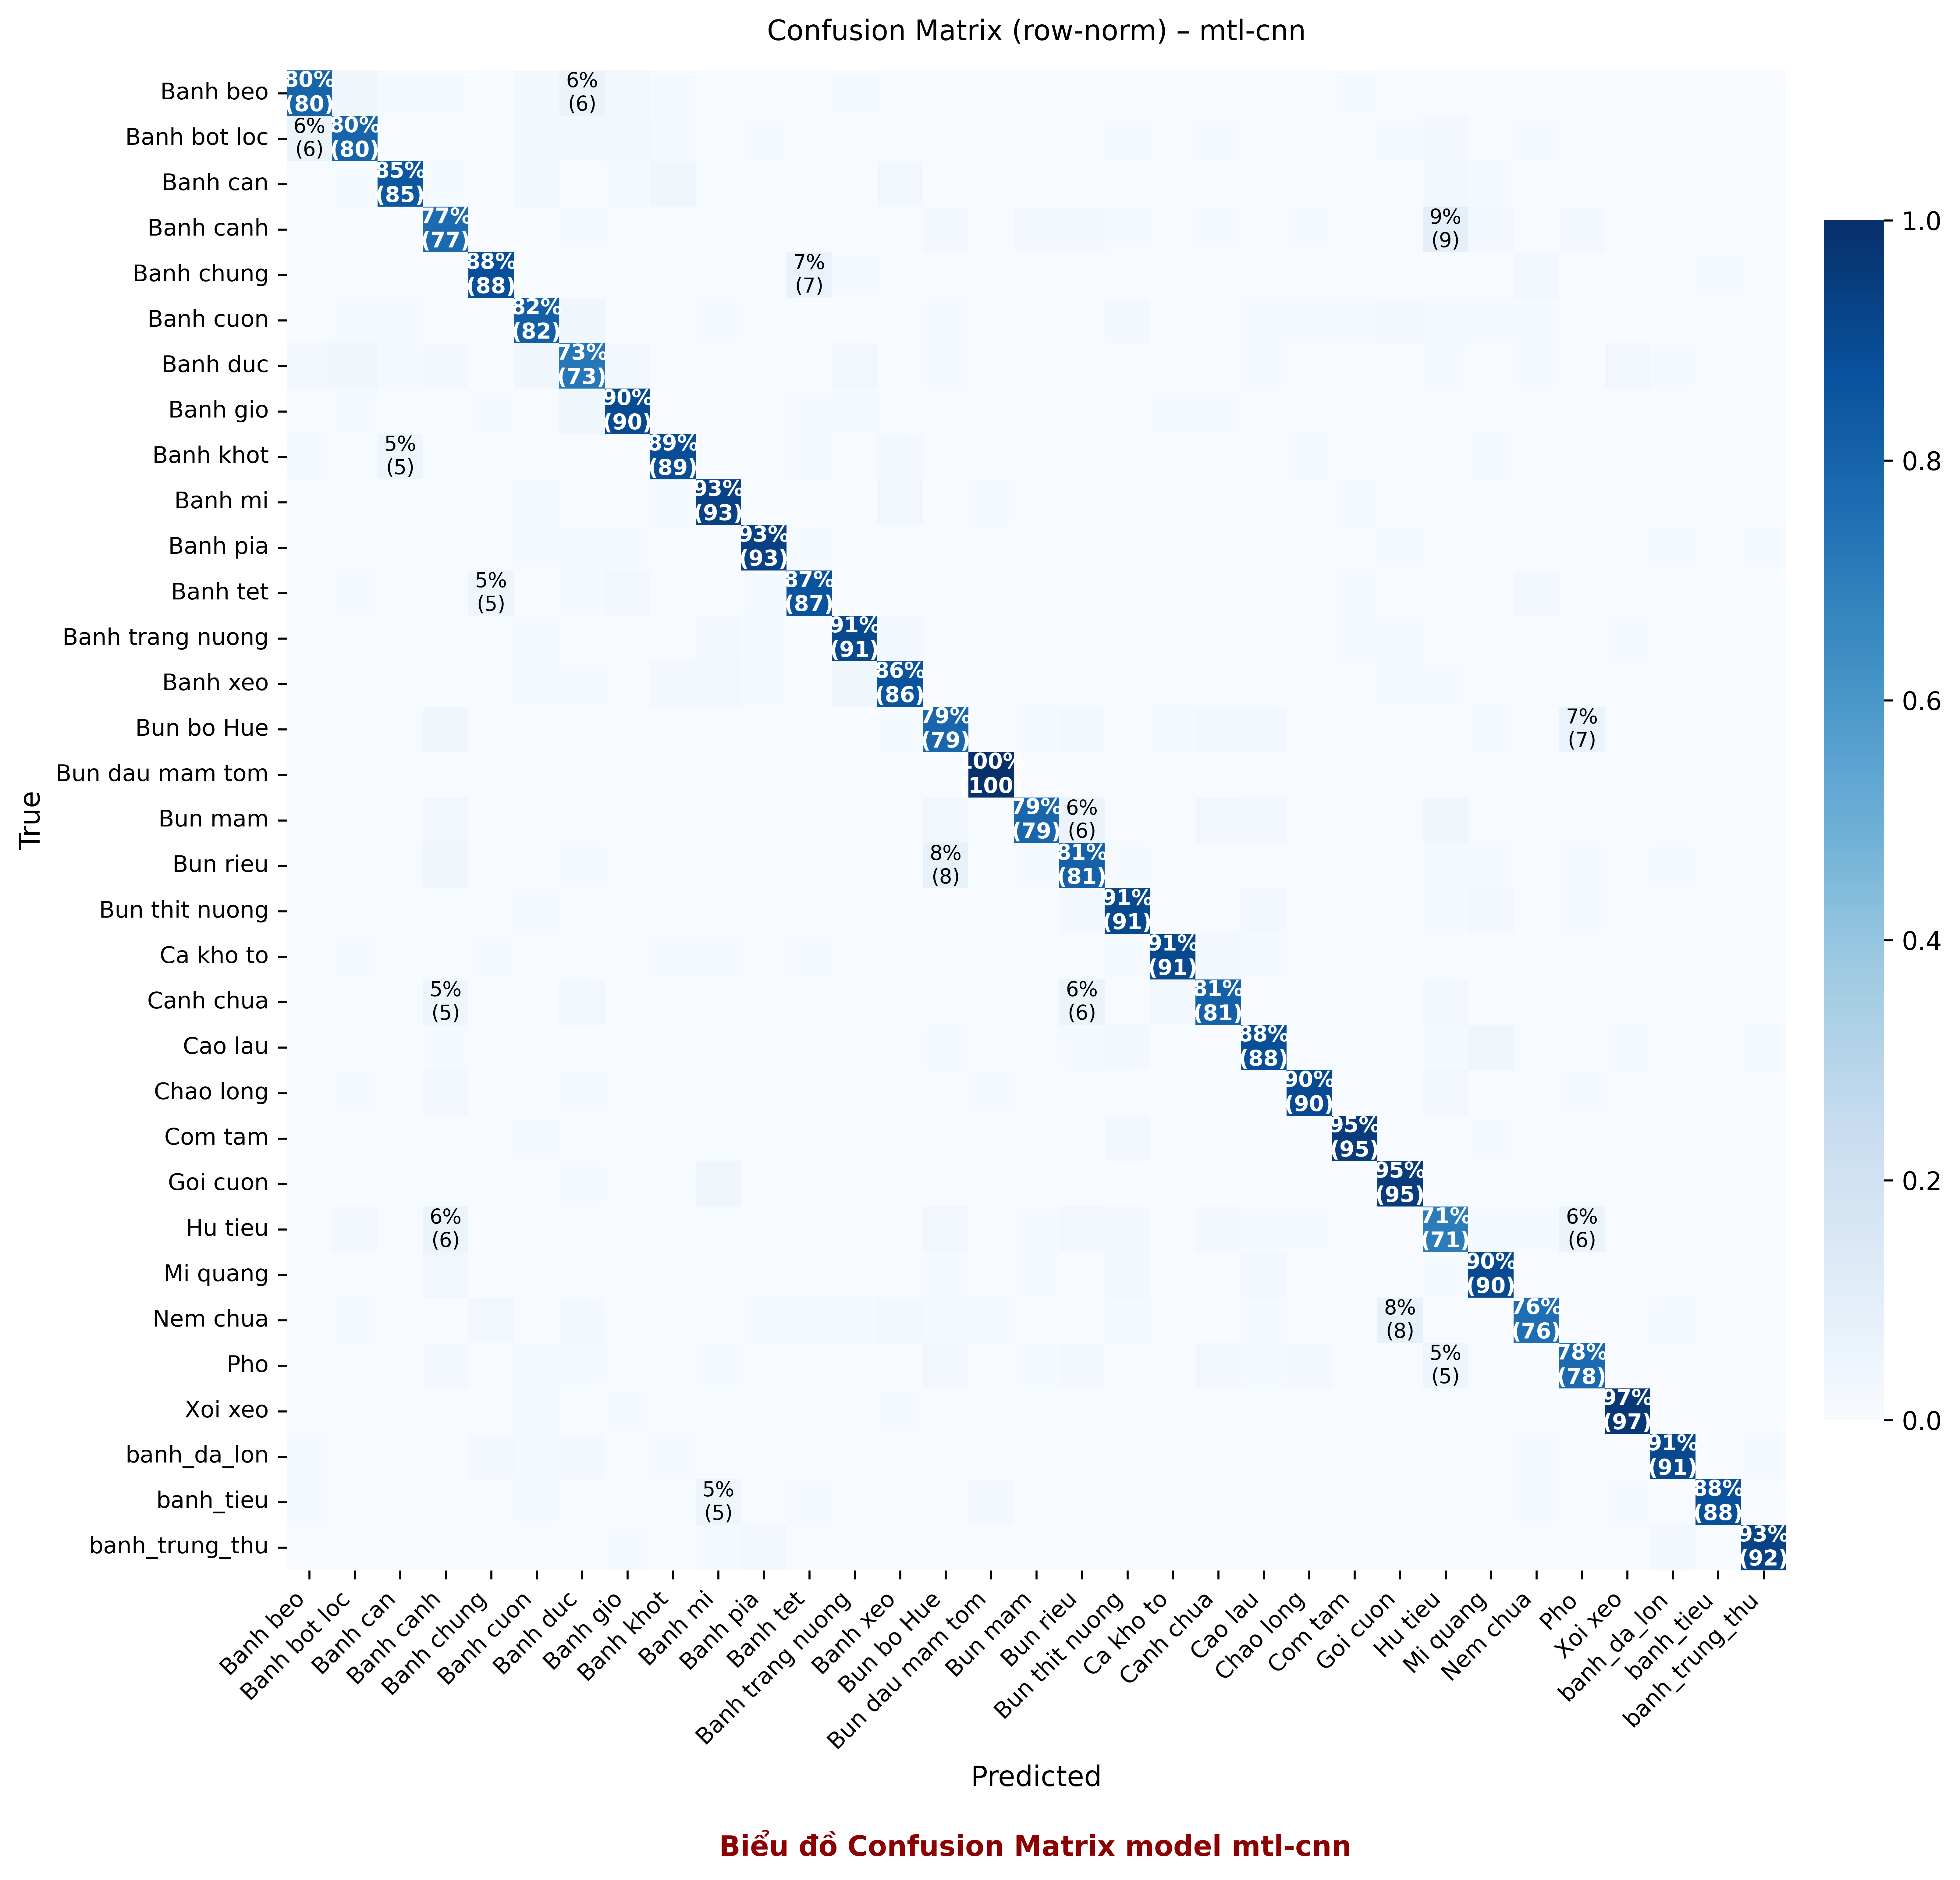

TypeError: cannot unpack non-iterable NoneType object

In [303]:
# Gọi chạy
# Sửa đường dẫn đúng checkpoint bạn muốn đánh giá
ckpt = "./runs/mtl_efficientnet_b0-20251110-203539/checkpoints/best.mtl"
result = evaluate_checkpoint(ckpt_path=ckpt, run_name="mtl_efficientnet_b0-20251110-203539", topk_curves=5, show_errors=16)
#result


In [ ]:
from pathlib import Path
import os
from typing import Optional, Tuple, List

RUNS_DIR = Path("./runs")

def pick_checkpoint(run_path: Path) -> Optional[Path]:
    """
    Ưu tiên:
      1) checkpoints/best.mtl
      2) checkpoints/best.pt / .pth
      3) checkpoints/last.mtl / .pt / .pth
      4) bất kỳ file .mtl/.pt/.pth trong checkpoints/
      5) fallback: .mtl/.pt/.pth ngay dưới run_path
    """
    run_path = Path(run_path)
    cand = [
        run_path/"checkpoints"/"best.mtl",
        run_path/"checkpoints"/"best.pt",
        run_path/"checkpoints"/"best.pth",
        run_path/"checkpoints"/"last.mtl",
        run_path/"checkpoints"/"last.pt",
        run_path/"checkpoints"/"last.pth",
    ]
    for p in cand:
        if p.exists(): return p

    ckdir = run_path/"checkpoints"
    if ckdir.exists():
        for p in sorted(ckdir.iterdir()):
            if p.suffix.lower() in [".mtl", ".pt", ".pth"]:
                return p

    for p in sorted(run_path.iterdir()):
        if p.suffix.lower() in [".mtl", ".pt", ".pth"]:
            return p

    return None


In [ ]:
import pandas as pd

def evaluate_one_run(run_path: Path,
                     img_size: int = IMG_SIZE,
                     batch_size: int = BATCH,
                     topk_curves: int = 5,
                     show_errors: int = 12):
    """
    Trả về dict kết quả + vẽ CM/ROC + lưới ảnh lỗi (n ảnh).
    """
    run_path = Path(run_path)
    run_name = run_path.name
    ckpt = pick_checkpoint(run_path)
    if not ckpt:
        print(f"[skip] {run_name}: không tìm thấy checkpoint.")
        return None

    print(f"=== Đánh giá: {run_name} ===")
    model, _, _, _, _ = load_checkpoint_safely(ckpt, num_classes=NUM_CLASSES, device=DEVICE)

    # loader
    test_loader, _ = build_test_loader(TEST_DIR, img_size, batch_size)

    # logits
    y_true, y_prob, y_pred, paths = collect_logits(model, test_loader, DEVICE)

    # scores
    acc, pre, rec, f1 = compute_scores(y_true, y_pred)
    print(f"[acc={acc:.4f}]  [macro P/R/F1 = {pre:.4f}/{rec:.4f}/{f1:.4f}]")

    # CM
    cm_png = IMAGES_DIR / f"{run_name}_cm.png"
    cm, cm_row = plot_confusion_matrix(
        y_true, y_pred, CLASS_NAMES,
        title=f"Confusion Matrix (row-norm) – {run_name}",
        out_png=cm_png
    )
    show_top_confused(cm, cm_row, CLASS_NAMES, topn=20)

    # ROC
    macro_auc, aucs = plot_roc_ovr(
        y_true, y_prob, CLASS_NAMES,
        run_label=run_name, topk_curves=topk_curves, out_dir=IMAGES_DIR
    )

    # lỗi
    show_errors_grid(paths, y_true, y_pred, y_prob, CLASS_NAMES, n=show_errors, cols=4, img_size=160)

    # speed
    speed = benchmark_speed(model, input_size=(1,3,img_size,img_size), repeat=60, warmup=15, device=DEVICE)

    res = dict(
        run=run_name,
        ckpt=str(ckpt),
        acc=float(acc),
        precision=float(pre),
        recall=float(rec),
        f1=float(f1),
        macro_auc=float(macro_auc),
        fps=float(speed['fps']),
        latency_ms=float(speed['latency_ms']),
        params_m=float(speed['params']/1e6),
        model_size_mb=float(speed['size_mb']),
        cm_png=str(cm_png),
        roc_png=str(IMAGES_DIR / f"{run_name}_roc.png"),
        img_size=img_size,
        batch_size=batch_size,
    )
    return res


In [ ]:
def evaluate_three_runs(runs_dir: Path = RUNS_DIR,
                        pick_three: List[str] | None = None,
                        sort_key: str = "name"):
    """
    pick_three: list tên thư mục run muốn đánh giá (ví dụ: ["mtl-efficientnet_b0-2025....", ...])
                Nếu None => tự lấy 3 run mới nhất.
    sort_key: "name" hoặc "mtime"
    """
    runs_dir = Path(runs_dir)
    all_runs = [d for d in sorted(runs_dir.iterdir()) if d.is_dir()]
    if not all_runs:
        print("Không có run nào trong thư mục:", runs_dir)
        return []

    if pick_three:
        run_paths = [runs_dir / r for r in pick_three]
        run_paths = [p for p in run_paths if p.exists()]
    else:
        if sort_key == "mtime":
            all_runs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        # default: tên tăng dần → lấy 3 cuối coi như mới nhất
        run_paths = all_runs[-3:]

    results = []
    for rp in run_paths:
        r = evaluate_one_run(rp)
        if r: results.append(r)

    return results


In [ ]:
def render_ranking_table(results: list, sort_by: str = "acc", out_png: Path | None = None):
    if not results:
        print("Không có kết quả để xếp hạng.")
        return None

    df = pd.DataFrame(results).sort_values(sort_by, ascending=False).reset_index(drop=True)
    display(df[["run","acc","precision","recall","f1","macro_auc","fps","latency_ms","params_m","model_size_mb","img_size","batch_size"]])

    # vẽ bảng gọn lưu PNG
    fig, ax = plt.subplots(figsize=(10, 0.45*len(df)+1), dpi=220)
    ax.axis("off")
    tbl = ax.table(
        cellText=np.round(df[["acc","precision","recall","f1","macro_auc","fps","latency_ms","params_m","model_size_mb"]].values, 4),
        rowLabels=df["run"].tolist(),
        colLabels=["acc","prec","rec","f1","AUC","fps","latency(ms)","params(M)","size(MB)"],
        loc="center",
        cellLoc="center"
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.25)
    plt.tight_layout()

    if out_png is None:
        out_png = IMAGES_DIR / "summary_models.png"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    print("✓ Lưu bảng xếp hạng:", out_png)
    plt.show()
    return df

# ===== GỌI CHẠY (chọn 1 trong 2 cách) =====
# Cách 1: chỉ đích danh 3 run muốn so
# results = evaluate_three_runs(RUNS_DIR, pick_three=[
#     "mtl_efficientnet_b0-20251110-203539",
#     "mtl-mobilenetv4-20251029-223758",
#     "mtl-cnn-20251029-201543",
# ])

# Cách 2: để None → tự lấy 3 run mới nhất trong RUNS_DIR
results = evaluate_three_runs(RUNS_DIR, pick_three=None)

df_rank = render_ranking_table(results, sort_by="acc", out_png=IMAGES_DIR/"summary_models.png")
df_rank
